In [1]:
print("Hello")

Hello


In [2]:
import os
import cv2
import numpy as np
import supervision as sv

import torch
import torchvision

from groundingdino.util.inference import Model
from segment_anything import SamPredictor
from LightHQSAM.setup_light_hqsam import setup_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# GroundingDINO config and checkpoint

BASE_PATH = "/home/saige/Workspace/Grounded-Segment-Anything/"
GROUNDING_DINO_CONFIG_PATH = os.path.join(BASE_PATH,"GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py")
GROUNDING_DINO_CHECKPOINT_PATH = os.path.join(BASE_PATH,"groundingdino_swint_ogc.pth")

# Building GroundingDINO inference model
grounding_dino_model = Model(model_config_path=GROUNDING_DINO_CONFIG_PATH, model_checkpoint_path=GROUNDING_DINO_CHECKPOINT_PATH, device=DEVICE)

# Building MobileSAM predictor
HQSAM_CHECKPOINT_PATH = os.path.join(BASE_PATH,"EfficientSAM/sam_hq_vit_tiny.pth")
checkpoint = torch.load(HQSAM_CHECKPOINT_PATH, map_location=DEVICE)
light_hqsam = setup_model()
light_hqsam.load_state_dict(checkpoint, strict=True)
light_hqsam.to(device=DEVICE)

sam_predictor = SamPredictor(light_hqsam)


grounding_dino_model.model.eval()
sam_predictor.model.eval()

# Predict classes and hyper-param for GroundingDINO
SOURCE_IMAGE_PATH = os.path.join(BASE_PATH,"./EfficientSAM/LightHQSAM/example_light_hqsam.png")
CLASSES = ["bench"]
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25
NMS_THRESHOLD = 0.8


# load image
image = cv2.imread(SOURCE_IMAGE_PATH)

# detect objects
detections = grounding_dino_model.predict_with_classes(
    image=image,
    classes=CLASSES,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD
)

# annotate image with detections
box_annotator = sv.BoxAnnotator()
labels = [
    f"{CLASSES[class_id]} {confidence:0.2f}" 
    for _, _, confidence, class_id, _, _
    in detections]
annotated_frame = box_annotator.annotate(scene=image.copy(), detections=detections, labels=labels)

# NMS post process
print(f"Before NMS: {len(detections.xyxy)} boxes")
nms_idx = torchvision.ops.nms(
    torch.from_numpy(detections.xyxy), 
    torch.from_numpy(detections.confidence), 
    NMS_THRESHOLD
).numpy().tolist()

detections.xyxy = detections.xyxy[nms_idx]
detections.confidence = detections.confidence[nms_idx]
detections.class_id = detections.class_id[nms_idx]

print(f"After NMS: {len(detections.xyxy)} boxes")

# Prompting SAM with detected boxes
def segment(sam_predictor: SamPredictor, image: np.ndarray, xyxy: np.ndarray) -> np.ndarray:
    sam_predictor.set_image(image)
    result_masks = []
    for box in xyxy:
        masks, scores, logits = sam_predictor.predict(
            box=box,
            multimask_output=False,
            hq_token_only=True,
        )
        index = np.argmax(scores)
        result_masks.append(masks[index])
    return np.array(result_masks)


# convert detections to masks
detections.mask = segment(
    sam_predictor=sam_predictor,
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    xyxy=detections.xyxy
)

# annotate image with detections
box_annotator = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator()
labels = [
    f"{CLASSES[class_id]} {confidence:0.2f}" 
    for _, _, confidence, class_id, _, _
    in detections]
annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

final text_encoder_type: bert-base-uncased


Before NMS: 1 boxes
After NMS: 1 boxes


SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead
SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


In [3]:
detections.mask

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(1, 1024, 1024))

In [4]:
import matplotlib.pyplot as plt

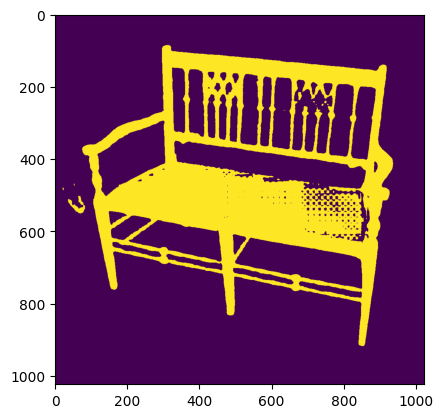

In [6]:
plt.imshow(detections.mask[0])

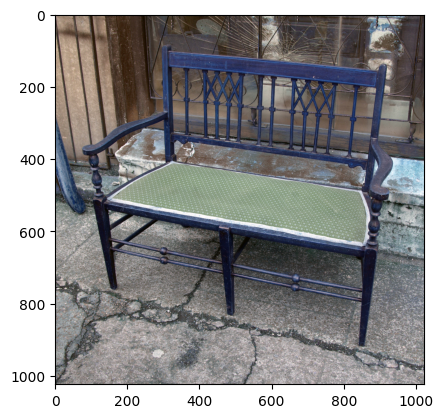

In [7]:
plt.imshow(image)

In [8]:
image.shape

(1024, 1024, 3)

In [12]:
mask = np.array(detections.mask[0])

In [19]:
mask_uint8 = mask.astype(np.uint8) * 255

In [20]:
cv2.imwrite("mask.png",mask_uint8)

True